# 🏥 Medical Treatment Recommendation Model
### Hackathon Notebook — Full Pipeline

**Task:** Given patient info (age, sex, etc.) + dementia severity + tumor type → predict best treatment.

**Datasets used:**
- [Falah/Alzheimer_MRI](https://huggingface.co/datasets/Falah/Alzheimer_MRI) — dementia severity classification
- [Simezu/brain-tumour-MRI-scan](https://huggingface.co/datasets/Simezu/brain-tumour-MRI-scan) — tumor type classification
- [BraTS2020](https://www.kaggle.com/datasets/awsaf49/brats2020-training-data) — optional advanced MRI segmentation

---
<a id='step1'></a>
## 📦 STEP 1 — Install Dependencies

In [1]:
# Run this cell first — installs everything you need
!pip install datasets transformers torch torchvision pillow scikit-learn pandas numpy matplotlib seaborn huggingface_hub kaggle -q

In [2]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
print('All imports successful ✅')

Using device: cpu
All imports successful ✅


---
<a id='step2'></a>
## 📊 STEP 2 — Load & Explore Datasets

We have **two HuggingFace datasets** and **one Kaggle dataset**.
- The HF ones load automatically.
- For BraTS2020, you need a Kaggle API key (instructions below). It's optional for this pipeline.

### 2A. Load Alzheimer/Dementia Dataset

In [3]:
print('Loading Alzheimer MRI dataset...')
alzheimer_ds = load_dataset('Falah/Alzheimer_MRI')
print(alzheimer_ds)

# Label mapping: 0=Mild_Demented, 1=Moderate_Demented, 2=Non_Demented, 3=Very_Mild_Demented
DEMENTIA_LABELS = alzheimer_ds['train'].features['label'].names
print('\nDementia classes:', DEMENTIA_LABELS)
print('Train samples:', len(alzheimer_ds['train']))
print('Test samples:', len(alzheimer_ds['test']))

Loading Alzheimer MRI dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…):   0%|          | 0.00/22.6M [00:00<?, ?B/s]

data/test-00000-of-00001-44110b9df98c558(…):   0%|          | 0.00/5.65M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 5120
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1280
    })
})

Dementia classes: ['Mild_Demented', 'Moderate_Demented', 'Non_Demented', 'Very_Mild_Demented']
Train samples: 5120
Test samples: 1280


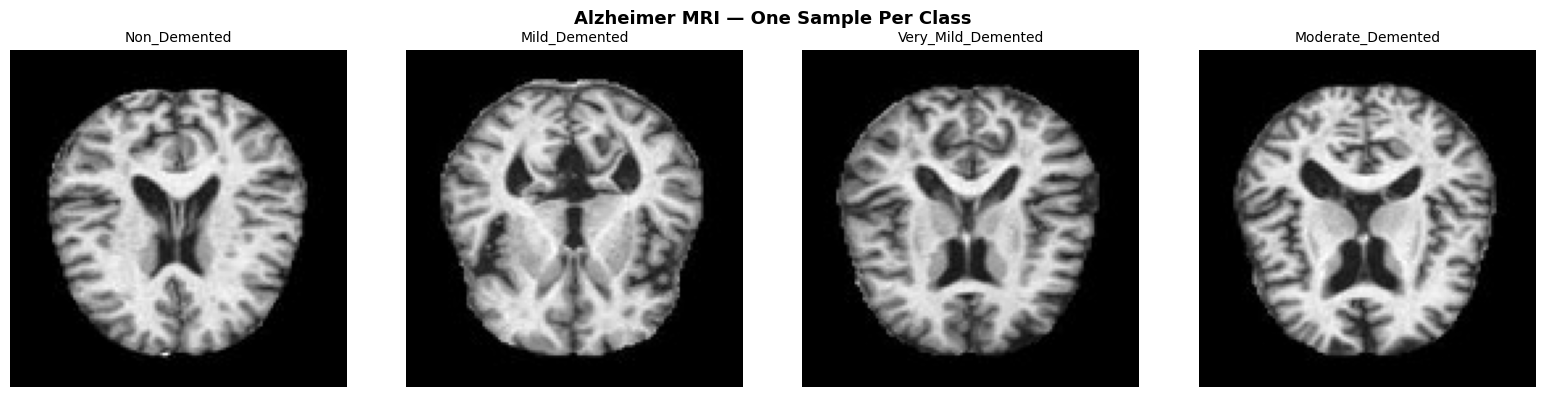

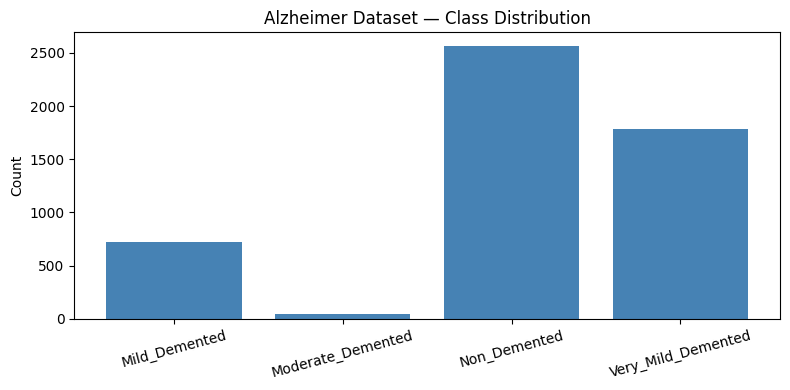

In [4]:
# Visualize sample MRI images from Alzheimer dataset
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
shown = set()
idx = 0
for sample in alzheimer_ds['train']:
    label = sample['label']
    if label not in shown:
        axes[idx].imshow(sample['image'], cmap='gray')
        axes[idx].set_title(DEMENTIA_LABELS[label], fontsize=10)
        axes[idx].axis('off')
        shown.add(label)
        idx += 1
    if idx == 4:
        break
plt.suptitle('Alzheimer MRI — One Sample Per Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Label distribution
from collections import Counter
label_counts = Counter(alzheimer_ds['train']['label'])
plt.figure(figsize=(8, 4))
plt.bar([DEMENTIA_LABELS[k] for k in sorted(label_counts)], [label_counts[k] for k in sorted(label_counts)], color='steelblue')
plt.title('Alzheimer Dataset — Class Distribution')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 2B. Load Brain Tumor Dataset

In [ ]:
print('Loading Brain Tumour MRI dataset...')
tumor_ds = load_dataset('Simezu/brain-tumour-MRI-scan')
print(tumor_ds)

TUMOR_LABELS = tumor_ds['train'].features['label'].names
print('\nTumor classes:', TUMOR_LABELS)
print('Train samples:', len(tumor_ds['train']))
print('Test samples:', len(tumor_ds['test']))

Loading Brain Tumour MRI dataset...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/5712 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1311 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/5712 [00:00<?, ?it/s]

...

Training/1-notumor/Tr-no_0891.jpg:   0%|          | 0.00/9.23k [00:00<?, ?B/s]

Training/1-notumor/Tr-no_0892.jpg:   0%|          | 0.00/31.2k [00:00<?, ?B/s]

Training/1-notumor/Tr-no_0893.jpg:   0%|          | 0.00/39.4k [00:00<?, ?B/s]

Training/1-notumor/Tr-no_0894.jpg:   0%|          | 0.00/29.0k [00:00<?, ?B/s]

Training/1-notumor/Tr-no_0895.jpg:   0%|          | 0.00/13.0k [00:00<?, ?B/s]

In [ ]:
# Visualize brain tumor samples
fig, axes = plt.subplots(1, len(TUMOR_LABELS), figsize=(4*len(TUMOR_LABELS), 4))
if len(TUMOR_LABELS) == 1:
    axes = [axes]
shown = set()
idx = 0
for sample in tumor_ds['train']:
    label = sample['label']
    if label not in shown:
        axes[idx].imshow(sample['image'], cmap='gray')
        axes[idx].set_title(TUMOR_LABELS[label], fontsize=10)
        axes[idx].axis('off')
        shown.add(label)
        idx += 1
    if idx == len(TUMOR_LABELS):
        break
plt.suptitle('Brain Tumor MRI — One Sample Per Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2C. (Optional) Download BraTS2020 from Kaggle

BraTS2020 is large (~20GB) — only use it if you want advanced tumor segmentation. Skip for hackathon speed.

**To use Kaggle API:**
1. Go to kaggle.com → Account → Create API Token → downloads `kaggle.json`
2. Place `kaggle.json` at `~/.kaggle/kaggle.json`
3. Run the cell below

In [ ]:
# OPTIONAL — only run if you want BraTS2020
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/  # place your kaggle.json in the same folder as this notebook
# !chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d awsaf49/brats2020-training-data --unzip -p ./brats2020
print('BraTS2020 download skipped (uncomment above lines to enable)')
print('For this hackathon pipeline, we use the two HuggingFace datasets which are sufficient.')

---
<a id='step3'></a>
## 🧑‍⚕️ STEP 3 — Build Synthetic Patient Dataset

The MRI datasets don't include patient metadata (age, sex, etc.) or treatment labels.
We'll generate a **realistic synthetic patient table** that combines:
- Patient demographics (age, sex, comorbidities)
- Dementia severity (from classifier or known label)
- Tumor type (from classifier or known label)
- **Treatment recommendation** (rule-based ground truth)

This is standard practice in medical AI when structured EHR data is unavailable.

In [ ]:
# Treatment mapping — medically informed rules
# In real scenarios this would come from clinical guidelines / expert annotation

DEMENTIA_SEVERITY_MAP = {
    'Non_Demented': 0,
    'Very_Mild_Demented': 1,
    'Mild_Demented': 2,
    'Moderate_Demented': 3
}

TUMOR_TYPE_MAP = {
    'notumor': 0,
    'meningioma': 1,
    'glioma': 2,
    'pituitary': 3
}

# Treatment options
TREATMENTS = [
    'Watchful Waiting + Lifestyle Modification',      # 0
    'Cholinesterase Inhibitors (e.g. Donepezil)',     # 1
    'Memantine + Cholinesterase Inhibitors',           # 2
    'Surgical Resection',                              # 3
    'Radiation Therapy',                               # 4
    'Chemotherapy (Temozolomide)',                     # 5
    'Combined Chemo-Radiation',                        # 6
    'Hormone Therapy + Surgery',                       # 7
    'Palliative/Supportive Care',                      # 8
]

def assign_treatment(age, sex, dementia_severity, tumor_type, has_hypertension, has_diabetes):
    """Rule-based treatment assignment (acts as ground truth for training)."""
    
    # High-risk patient flag
    high_risk = age > 70 or has_hypertension or has_diabetes
    
    # No tumor cases — dementia-driven treatment
    if tumor_type == 'notumor':
        if dementia_severity == 'Non_Demented':
            return 'Watchful Waiting + Lifestyle Modification'
        elif dementia_severity == 'Very_Mild_Demented':
            return 'Cholinesterase Inhibitors (e.g. Donepezil)'
        elif dementia_severity == 'Mild_Demented':
            return 'Memantine + Cholinesterase Inhibitors'
        else:  # Moderate
            return 'Palliative/Supportive Care' if high_risk else 'Memantine + Cholinesterase Inhibitors'
    
    # Tumor present — tumor type drives primary treatment
    elif tumor_type == 'meningioma':
        return 'Palliative/Supportive Care' if high_risk and dementia_severity == 'Moderate_Demented' else 'Surgical Resection'
    
    elif tumor_type == 'glioma':
        if age > 70 or dementia_severity == 'Moderate_Demented':
            return 'Radiation Therapy'  # less aggressive for elderly/severe dementia
        return 'Combined Chemo-Radiation'
    
    elif tumor_type == 'pituitary':
        return 'Hormone Therapy + Surgery'
    
    return 'Watchful Waiting + Lifestyle Modification'


print('Treatment rule engine defined ✅')

In [ ]:
# Generate synthetic patient records
np.random.seed(SEED)

N = 2000  # number of synthetic patients

tumor_type_list = list(TUMOR_TYPE_MAP.keys())
dementia_list = list(DEMENTIA_SEVERITY_MAP.keys())

patients = []
for i in range(N):
    age = int(np.random.normal(65, 12))
    age = np.clip(age, 30, 95)
    sex = np.random.choice(['Male', 'Female'])
    dementia_severity = np.random.choice(dementia_list, p=[0.1, 0.25, 0.45, 0.20])
    tumor_type = np.random.choice(tumor_type_list, p=[0.40, 0.20, 0.25, 0.15])
    has_hypertension = np.random.choice([0, 1], p=[0.55, 0.45])
    has_diabetes = np.random.choice([0, 1], p=[0.70, 0.30])
    mmse_score = int(np.random.normal(20, 6))  # Mini-Mental State Exam score
    mmse_score = np.clip(mmse_score, 0, 30)
    
    treatment = assign_treatment(age, sex, dementia_severity, tumor_type, has_hypertension, has_diabetes)
    
    patients.append({
        'patient_id': f'P{i+1:04d}',
        'age': age,
        'sex': sex,
        'mmse_score': mmse_score,
        'has_hypertension': has_hypertension,
        'has_diabetes': has_diabetes,
        'dementia_severity': dementia_severity,
        'tumor_type': tumor_type,
        'treatment': treatment
    })

df = pd.DataFrame(patients)
print(f'Generated {N} synthetic patient records')
print(df.head(10))
print('\nTreatment distribution:')
print(df['treatment'].value_counts())

In [ ]:
# Save patient dataset
df.to_csv('synthetic_patients.csv', index=False)

# Visualize treatment distribution
plt.figure(figsize=(12, 5))
df['treatment'].value_counts().plot(kind='barh', color='teal')
plt.title('Treatment Distribution in Synthetic Dataset')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

---
<a id='step4'></a>
## 🧠 STEP 4 — Train Dementia Severity Classifier (CNN)

We fine-tune a **ResNet-18** on the Alzheimer MRI dataset to predict dementia severity from brain MRI scans.
This model will be one component of the full pipeline.

In [ ]:
# PyTorch Dataset wrapper for HuggingFace image datasets
class HFImageDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.data = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        image = sample['image'].convert('RGB')  # ensure 3-channel
        label = sample['label']
        if self.transform:
            image = self.transform(image)
        return image, label


# Transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Datasets & loaders
alz_train_ds = HFImageDataset(alzheimer_ds['train'], transform=train_transform)
alz_val_ds   = HFImageDataset(alzheimer_ds['test'],  transform=val_transform)

alz_train_loader = DataLoader(alz_train_ds, batch_size=32, shuffle=True,  num_workers=2)
alz_val_loader   = DataLoader(alz_val_ds,   batch_size=32, shuffle=False, num_workers=2)

print(f'Train batches: {len(alz_train_loader)} | Val batches: {len(alz_val_loader)}')

In [ ]:
def build_resnet_classifier(num_classes, pretrained=True):
    """Load ResNet-18 and replace the final FC layer."""
    model = models.resnet18(weights='DEFAULT' if pretrained else None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


print('Training utilities defined ✅')

In [ ]:
# ─── Train Dementia Classifier ───
NUM_EPOCHS_DEMENTIA = 3  # Increase to 20-30 for better accuracy

dementia_model = build_resnet_classifier(num_classes=len(DEMENTIA_LABELS)).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(dementia_model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS_DEMENTIA)

dementia_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print('Training Dementia Severity Classifier...')
print(f'Classes: {DEMENTIA_LABELS}')
print('-' * 60)

for epoch in range(1, NUM_EPOCHS_DEMENTIA + 1):
    tr_loss, tr_acc = train_one_epoch(dementia_model, alz_train_loader, optimizer, criterion, DEVICE)
    vl_loss, vl_acc, _, _ = evaluate(dementia_model, alz_val_loader, criterion, DEVICE)
    scheduler.step()
    
    dementia_history['train_loss'].append(tr_loss)
    dementia_history['val_loss'].append(vl_loss)
    dementia_history['train_acc'].append(tr_acc)
    dementia_history['val_acc'].append(vl_acc)
    
    print(f'Epoch {epoch:2d}/{NUM_EPOCHS_DEMENTIA} | '
          f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.3f} | '
          f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.3f}')

print('\nTraining complete ✅')

In [ ]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(dementia_history['train_loss'], label='Train')
ax1.plot(dementia_history['val_loss'], label='Val')
ax1.set_title('Dementia Classifier — Loss')
ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(dementia_history['train_acc'], label='Train')
ax2.plot(dementia_history['val_acc'], label='Val')
ax2.set_title('Dementia Classifier — Accuracy')
ax2.set_xlabel('Epoch'); ax2.legend()
plt.tight_layout(); plt.show()

# Final evaluation
_, _, preds, labels = evaluate(dementia_model, alz_val_loader, criterion, DEVICE)
print('\nClassification Report — Dementia Classifier:')
print(classification_report(labels, preds, target_names=DEMENTIA_LABELS))

# Save model
torch.save(dementia_model.state_dict(), 'dementia_classifier.pt')
print('Model saved to dementia_classifier.pt ✅')

---
<a id='step5'></a>
## 🫁 STEP 5 — Train Tumor Type Classifier (CNN)

In [ ]:
# Dataset loaders for Tumor
tumor_train_ds = HFImageDataset(tumor_ds['train'], transform=train_transform)
tumor_val_ds   = HFImageDataset(tumor_ds['test'],  transform=val_transform)

tumor_train_loader = DataLoader(tumor_train_ds, batch_size=32, shuffle=True,  num_workers=2)
tumor_val_loader   = DataLoader(tumor_val_ds,   batch_size=32, shuffle=False, num_workers=2)

print(f'Tumor train batches: {len(tumor_train_loader)} | Val batches: {len(tumor_val_loader)}')
print(f'Classes: {TUMOR_LABELS}')

In [ ]:
# ─── Train Tumor Classifier ───
NUM_EPOCHS_TUMOR = 3

tumor_model = build_resnet_classifier(num_classes=len(TUMOR_LABELS)).to(DEVICE)
optimizer_t = optim.AdamW(tumor_model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler_t = optim.lr_scheduler.CosineAnnealingLR(optimizer_t, T_max=NUM_EPOCHS_TUMOR)

tumor_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print('Training Tumor Type Classifier...')
print('-' * 60)

for epoch in range(1, NUM_EPOCHS_TUMOR + 1):
    tr_loss, tr_acc = train_one_epoch(tumor_model, tumor_train_loader, optimizer_t, criterion, DEVICE)
    vl_loss, vl_acc, _, _ = evaluate(tumor_model, tumor_val_loader, criterion, DEVICE)
    scheduler_t.step()
    
    tumor_history['train_loss'].append(tr_loss)
    tumor_history['val_loss'].append(vl_loss)
    tumor_history['train_acc'].append(tr_acc)
    tumor_history['val_acc'].append(vl_acc)
    
    print(f'Epoch {epoch:2d}/{NUM_EPOCHS_TUMOR} | '
          f'Train Loss: {tr_loss:.4f} Acc: {tr_acc:.3f} | '
          f'Val Loss: {vl_loss:.4f} Acc: {vl_acc:.3f}')

print('\nTraining complete ✅')

# Evaluation
_, _, preds_t, labels_t = evaluate(tumor_model, tumor_val_loader, criterion, DEVICE)
print('\nClassification Report — Tumor Classifier:')
print(classification_report(labels_t, preds_t, target_names=TUMOR_LABELS))

torch.save(tumor_model.state_dict(), 'tumor_classifier.pt')
print('Model saved to tumor_classifier.pt ✅')

---
<a id='step6'></a>
## 💊 STEP 6 — Train Treatment Recommender

Now the main model: a **Gradient Boosting Classifier** that takes:
- Patient demographics (age, sex, comorbidities, MMSE score)
- Predicted dementia severity
- Predicted tumor type

And outputs the recommended treatment.

In [ ]:
# Prepare feature matrix from synthetic patient data
df = pd.read_csv('synthetic_patients.csv')

# Encode categorical features
sex_enc = LabelEncoder()
dementia_enc = LabelEncoder()
tumor_enc = LabelEncoder()
treatment_enc = LabelEncoder()

df['sex_enc'] = sex_enc.fit_transform(df['sex'])
df['dementia_enc'] = dementia_enc.fit_transform(df['dementia_severity'])
df['tumor_enc'] = tumor_enc.fit_transform(df['tumor_type'])
df['treatment_enc'] = treatment_enc.fit_transform(df['treatment'])

FEATURES = ['age', 'sex_enc', 'mmse_score', 'has_hypertension', 'has_diabetes', 'dementia_enc', 'tumor_enc']
TARGET = 'treatment_enc'

X = df[FEATURES].values
y = df[TARGET].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/val split
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=SEED, stratify=y)

print(f'Train: {X_train.shape} | Val: {X_val.shape}')
print(f'Treatment classes: {treatment_enc.classes_}')

In [ ]:
# ─── Train Gradient Boosting Treatment Recommender ───
from sklearn.ensemble import GradientBoostingClassifier

treatment_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=SEED
)

print('Training Treatment Recommender...')
treatment_model.fit(X_train, y_train)

val_preds = treatment_model.predict(X_val)
val_acc = accuracy_score(y_val, val_preds)
print(f'\nValidation Accuracy: {val_acc:.4f}')
print('\nClassification Report — Treatment Recommender:')
print(classification_report(y_val, val_preds, target_names=treatment_enc.classes_))

In [ ]:
# Feature importance
importances = treatment_model.feature_importances_
feat_names = ['Age', 'Sex', 'MMSE Score', 'Hypertension', 'Diabetes', 'Dementia Severity', 'Tumor Type']

plt.figure(figsize=(9, 5))
sorted_idx = np.argsort(importances)
plt.barh([feat_names[i] for i in sorted_idx], importances[sorted_idx], color='darkorange')
plt.title('Feature Importance — Treatment Recommender')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Confusion matrix
cm = confusion_matrix(y_val, val_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=treatment_enc.classes_,
            yticklabels=treatment_enc.classes_)
plt.title('Confusion Matrix — Treatment Recommender')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Save all models and encoders
import pickle

with open('treatment_model.pkl', 'wb') as f:
    pickle.dump(treatment_model, f)

with open('encoders_scaler.pkl', 'wb') as f:
    pickle.dump({
        'sex_enc': sex_enc,
        'dementia_enc': dementia_enc,
        'tumor_enc': tumor_enc,
        'treatment_enc': treatment_enc,
        'scaler': scaler,
        'features': FEATURES,
        'dementia_labels': DEMENTIA_LABELS,
        'tumor_labels': TUMOR_LABELS
    }, f)

print('All models and encoders saved ✅')

---
<a id='step7'></a>
## 🔬 STEP 7 — Full End-to-End Inference Pipeline

Given a **new patient** with:
- Demographics (age, sex, MMSE, comorbidities)
- Optional: brain MRI scan

→ Predicts dementia severity + tumor type from MRI → recommends treatment

In [ ]:
class TreatmentRecommendationPipeline:
    """End-to-end pipeline: MRI + Patient Info → Treatment Recommendation"""
    
    def __init__(self, dementia_model, tumor_model, treatment_model, encoders, device='cpu'):
        self.dementia_model = dementia_model.eval().to(device)
        self.tumor_model = tumor_model.eval().to(device)
        self.treatment_model = treatment_model
        self.device = device
        
        # Unpack encoders
        self.sex_enc = encoders['sex_enc']
        self.dementia_enc = encoders['dementia_enc']
        self.tumor_enc = encoders['tumor_enc']
        self.treatment_enc = encoders['treatment_enc']
        self.scaler = encoders['scaler']
        self.dementia_labels = encoders['dementia_labels']
        self.tumor_labels = encoders['tumor_labels']
        
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
    
    @torch.no_grad()
    def predict_from_mri(self, model, image_pil, label_names):
        """Run CNN inference on a PIL image."""
        img_tensor = self.transform(image_pil.convert('RGB')).unsqueeze(0).to(self.device)
        logits = model(img_tensor)
        probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
        pred_idx = probs.argmax()
        return label_names[pred_idx], {label_names[i]: float(probs[i]) for i in range(len(label_names))}
    
    def predict(
        self,
        age: int,
        sex: str,           # 'Male' or 'Female'
        mmse_score: int,
        has_hypertension: int,  # 0 or 1
        has_diabetes: int,      # 0 or 1
        dementia_mri: Image.Image = None,  # optional
        tumor_mri: Image.Image = None,     # optional
        dementia_severity_override: str = None,  # if known (skip MRI inference)
        tumor_type_override: str = None
    ):
        result = {'patient': {'age': age, 'sex': sex, 'mmse_score': mmse_score}}
        
        # Dementia severity
        if dementia_severity_override:
            dementia_severity = dementia_severity_override
            result['dementia_severity'] = dementia_severity
            result['dementia_probabilities'] = 'N/A (override)'
        elif dementia_mri:
            dementia_severity, dem_probs = self.predict_from_mri(self.dementia_model, dementia_mri, self.dementia_labels)
            result['dementia_severity'] = dementia_severity
            result['dementia_probabilities'] = dem_probs
        else:
            raise ValueError('Provide either dementia_mri or dementia_severity_override')
        
        # Tumor type
        if tumor_type_override:
            tumor_type = tumor_type_override
            result['tumor_type'] = tumor_type
            result['tumor_probabilities'] = 'N/A (override)'
        elif tumor_mri:
            tumor_type, tum_probs = self.predict_from_mri(self.tumor_model, tumor_mri, self.tumor_labels)
            result['tumor_type'] = tumor_type
            result['tumor_probabilities'] = tum_probs
        else:
            raise ValueError('Provide either tumor_mri or tumor_type_override')
        
        # Encode inputs for treatment model
        sex_encoded = self.sex_enc.transform([sex])[0]
        dementia_encoded = self.dementia_enc.transform([dementia_severity])[0]
        tumor_encoded = self.tumor_enc.transform([tumor_type])[0]
        
        features = np.array([[age, sex_encoded, mmse_score, has_hypertension, has_diabetes, dementia_encoded, tumor_encoded]])
        features_scaled = self.scaler.transform(features)
        
        # Predict treatment
        treatment_idx = self.treatment_model.predict(features_scaled)[0]
        treatment_probs = self.treatment_model.predict_proba(features_scaled)[0]
        treatment = self.treatment_enc.inverse_transform([treatment_idx])[0]
        
        result['recommended_treatment'] = treatment
        result['treatment_confidence'] = float(treatment_probs.max())
        result['top_3_treatments'] = [
            {'treatment': self.treatment_enc.inverse_transform([i])[0], 'probability': float(treatment_probs[i])}
            for i in treatment_probs.argsort()[-3:][::-1]
        ]
        
        return result


print('Pipeline class defined ✅')

In [ ]:
# Load models and initialize pipeline
import pickle

with open('encoders_scaler.pkl', 'rb') as f:
    encoders = pickle.load(f)

with open('treatment_model.pkl', 'rb') as f:
    loaded_treatment_model = pickle.load(f)

# Load CNN weights
loaded_dementia_model = build_resnet_classifier(num_classes=len(DEMENTIA_LABELS))
loaded_dementia_model.load_state_dict(torch.load('dementia_classifier.pt', map_location=DEVICE))

loaded_tumor_model = build_resnet_classifier(num_classes=len(TUMOR_LABELS))
loaded_tumor_model.load_state_dict(torch.load('tumor_classifier.pt', map_location=DEVICE))

pipeline = TreatmentRecommendationPipeline(
    dementia_model=loaded_dementia_model,
    tumor_model=loaded_tumor_model,
    treatment_model=loaded_treatment_model,
    encoders=encoders,
    device=DEVICE
)

print('Pipeline ready ✅')

In [ ]:
# ─── Demo Inference — using known labels (no MRI image needed) ───

test_cases = [
    dict(age=72, sex='Female', mmse_score=18, has_hypertension=1, has_diabetes=0,
         dementia_severity_override='Mild_Demented', tumor_type_override='notumor'),
    
    dict(age=55, sex='Male', mmse_score=26, has_hypertension=0, has_diabetes=0,
         dementia_severity_override='Non_Demented', tumor_type_override='glioma'),
    
    dict(age=68, sex='Female', mmse_score=22, has_hypertension=1, has_diabetes=1,
         dementia_severity_override='Very_Mild_Demented', tumor_type_override='meningioma'),
    
    dict(age=80, sex='Male', mmse_score=12, has_hypertension=1, has_diabetes=1,
         dementia_severity_override='Moderate_Demented', tumor_type_override='notumor'),
]

print('=' * 70)
print('TREATMENT RECOMMENDATION PIPELINE — DEMO')
print('=' * 70)

for i, case in enumerate(test_cases, 1):
    result = pipeline.predict(**case)
    print(f'\nPatient {i}: Age {result["patient"]["age"]}, {result["patient"]["sex"]}, MMSE {result["patient"]["mmse_score"]}')
    print(f'  Dementia Severity : {result["dementia_severity"]}')
    print(f'  Tumor Type        : {result["tumor_type"]}')
    print(f'  ✅ Recommended Treatment : {result["recommended_treatment"]}')
    print(f'  Confidence        : {result["treatment_confidence"]:.1%}')
    print(f'  Top 3 Options:')
    for t in result['top_3_treatments']:
        print(f'      {t["probability"]:.1%}  {t["treatment"]}')
    print('-' * 70)

In [ ]:
# ─── Demo Inference — using actual MRI images from test split ───

# Pick a real sample from test sets
alz_sample = alzheimer_ds['test'][5]
tum_sample  = tumor_ds['test'][10]

alz_image = alz_sample['image']
tum_image  = tum_sample['image']

print(f'True dementia label: {DEMENTIA_LABELS[alz_sample["label"]]}')
print(f'True tumor label   : {TUMOR_LABELS[tum_sample["label"]]}')

result = pipeline.predict(
    age=67, sex='Male', mmse_score=21,
    has_hypertension=0, has_diabetes=1,
    dementia_mri=alz_image,
    tumor_mri=tum_image
)

print('\n--- Pipeline Predictions ---')
print(f'Predicted Dementia Severity : {result["dementia_severity"]}')
print(f'Dementia Probabilities      : {result["dementia_probabilities"]}')
print(f'Predicted Tumor Type        : {result["tumor_type"]}')
print(f'Tumor Probabilities         : {result["tumor_probabilities"]}')
print(f'✅ Recommended Treatment    : {result["recommended_treatment"]}')
print(f'Confidence                  : {result["treatment_confidence"]:.1%}')

---
<a id='step8'></a>
## 💾 STEP 8 — Save Models (& Optionally Push to HuggingFace Hub)

Save everything needed so your teammate can reproduce/use your models.

In [ ]:
# Verify all output files exist
files = [
    'dementia_classifier.pt',
    'tumor_classifier.pt',
    'treatment_model.pkl',
    'encoders_scaler.pkl',
    'synthetic_patients.csv'
]

print('Output files:')
for f in files:
    size = Path(f).stat().st_size / 1024 if Path(f).exists() else 0
    status = '✅' if Path(f).exists() else '❌ MISSING'
    print(f'  {status}  {f}  ({size:.1f} KB)')

In [ ]:


print('HF Hub push is commented out — uncomment to enable')